# Lesson 06 — Paths, Cycles & Dependencies

## Learning Goal

Discover that systems depend on other systems in chains. Learn to find bottlenecks, identify critical paths, and design for resilience.

By the end of this lesson, you will:
- Find shortest paths (for fast recovery after failures)
- Identify critical paths (longest chain = bottleneck)
- Order systems respecting dependencies (topological sort)
- Detect and prevent circular dependencies (deadlocks)
- Identify single points of failure
- Design redundancy for resilience

**Duration**: 90 minutes

**Why this matters**: In distributed systems, a single failed service can cascade. Knowing which systems are on the critical path (longest dependency chain) lets you prioritize optimization and redundancy. Shortest paths tell you recovery speed. Topological sort prevents deployment deadlocks.

**Key Insight**: "Longest path = bottleneck." Everything in your system is limited by the slowest dependency chain. Find it, optimize it.

## Setup and Data Loading

In [ ]:
import sys
from pathlib import Path

# Add src directory to path
project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
sys.path.insert(0, str(project_root))

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# Load config or construct path manually
try:
    from src.config import Config
    DATA_DIR = Config.PROJECT_ROOT / 'data' / 'seed' / 'it_dependencies'
except ImportError:
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir.parent.parent if (notebook_dir.parent.parent / 'data').exists() else notebook_dir
    DATA_DIR = project_root / 'data' / 'seed' / 'it_dependencies'

def display_csv_head(df, name, n=5):
    """Display DataFrame info and head."""
    print(f"\n{name}:")
    print(f"  Shape: {df.shape} (rows, columns)")
    print(f"  Columns: {list(df.columns)}")
    print(f"\n  First {n} rows:")
    print(df.head(n).to_string(index=False))

# Load datasets
systems_df = pd.read_csv(DATA_DIR / 'systems.csv')
dependencies_df = pd.read_csv(DATA_DIR / 'dependencies.csv')
tasks_df = pd.read_csv(DATA_DIR / 'deployment_tasks.csv')

print("Data loaded successfully!")
print(f"  Systems: {len(systems_df)} microservices")
print(f"  Dependencies: {len(dependencies_df)} edges")
print(f"  Deployment tasks: {len(tasks_df)} tasks")

Data loaded successfully!
  Systems: 27 microservices
  Dependencies: 55 edges
  Deployment tasks: 27 tasks


## 1. Understanding System Dependencies

We have a **microservice architecture** with systems depending on other systems:

**Entities**:
- **Systems** (27): Microservices across 5 tiers (external, frontend, API, cache, database)
- **Dependencies** (55): Service-to-service edges; each edge = "depends on"
- **Attributes**: Latency, criticality, dependency type

**Key Questions**:
- What's the longest dependency chain? (critical path = bottleneck)
- If System X fails, which systems break? (failure impact)
- What's the fastest way to restart after failure? (shortest path by latency)
- In what order should we deploy? (topological sort)

**Key Insight**: "Longest path = the bottleneck limiting your entire system."

In [4]:
# Examine each dataset
display_csv_head(systems_df, "Systems", n=10)
display_csv_head(dependencies_df, "Dependencies (sample)", n=8)
display_csv_head(tasks_df, "Deployment Tasks (sample)", n=8)


Systems:
  Shape: (27, 6) (rows, columns)
  Columns: ['system_id', 'name', 'tier', 'latency_ms', 'criticality', 'is_external']

  First 10 rows:
system_id                 name     tier  latency_ms  criticality  is_external
   SYS_00       Stripe Payment external         137            3         True
   SYS_01       Auth0 Provider external         121            3         True
   SYS_02       SendGrid Email external         141            3         True
   SYS_03          Twillow SMS external         163            3         True
   SYS_04         Web Portal 1 frontend          25            4        False
   SYS_05    Admin Dashboard 2 frontend          25            4        False
   SYS_06 Mobile API Gateway 3 frontend          39            4        False
   SYS_07         Public API 4 frontend          33            4        False
   SYS_08       Auth Service 1      api          47            5        False
   SYS_09       User Service 2      api          63            5        Fa

In [5]:
# Basic statistics
print("Dataset Statistics:")
print(f"\nSystems by tier:")
print(systems_df['tier'].value_counts())
print(f"\nCriticality distribution:")
print(systems_df['criticality'].value_counts().sort_index())
print(f"\nLatency (ms) by tier:")
for tier in ['external', 'frontend', 'api', 'cache', 'database']:
    tier_latencies = systems_df[systems_df['tier'] == tier]['latency_ms'].describe()
    print(f"  {tier}: mean={tier_latencies['mean']:.0f}ms, min={tier_latencies['min']:.0f}ms, max={tier_latencies['max']:.0f}ms")

print(f"\nDependency types:")
print(dependencies_df['dependency_type'].value_counts())
print(f"\nCritical dependencies: {dependencies_df['is_critical'].sum()} / {len(dependencies_df)} ({100*dependencies_df['is_critical'].mean():.0f}%)")

Dataset Statistics:

Systems by tier:
tier
api         10
database     5
external     4
frontend     4
cache        4
Name: count, dtype: int64

Criticality distribution:
criticality
3     8
4     4
5    15
Name: count, dtype: int64

Latency (ms) by tier:
  external: mean=140ms, min=121ms, max=163ms
  frontend: mean=30ms, min=25ms, max=39ms
  api: mean=46ms, min=26ms, max=63ms
  cache: mean=5ms, min=3ms, max=7ms
  database: mean=171ms, min=93ms, max=300ms

Dependency types:
dependency_type
synchronous             41
asynchronous            10
eventual_consistency     4
Name: count, dtype: int64

Critical dependencies: 26 / 55 (47%)


## 2. Building the Dependency Graph

Create a **directed acyclic graph (DAG)** where systems are nodes and dependencies are edges.
Direction: A → B means "A depends on B"

In [6]:
# Create directed graph
G = nx.DiGraph()

# Add system nodes with attributes
for idx, row in systems_df.iterrows():
    G.add_node(
        row['system_id'],
        name=row['name'],
        tier=row['tier'],
        latency_ms=row['latency_ms'],
        criticality=row['criticality'],
        is_external=row['is_external']
    )

# Add dependency edges
for idx, row in dependencies_df.iterrows():
    from_sys = row['from_system_id']
    to_sys = row['to_system_id']
    G.add_edge(
        from_sys,
        to_sys,
        dependency_type=row['dependency_type'],
        latency_ms=row['latency_ms'],
        is_critical=row['is_critical']
    )

# Verify DAG
is_acyclic = nx.is_directed_acyclic_graph(G)
print(f"Dependency Graph Summary:")
print(f"  Nodes: {G.number_of_nodes()} systems")
print(f"  Edges: {G.number_of_edges()} dependencies")
print(f"  Is DAG (no cycles): {is_acyclic}")
print(f"  Density: {nx.density(G):.4f}")

if not is_acyclic:
    print("  ⚠️ WARNING: Graph has cycles! Some dependencies form loops.")
else:
    print(f"  ✓ Safe to deploy (no circular dependencies)")

Dependency Graph Summary:
  Nodes: 27 systems
  Edges: 55 dependencies
  Is DAG (no cycles): True
  Density: 0.0783
  ✓ Safe to deploy (no circular dependencies)


In [ ]:
# Sanity Checks: Graph Structure
print("\n" + "="*60)
print("SANITY CHECKS")
print("="*60)

# Check 1: Is it a DAG?
assert nx.is_directed_acyclic_graph(G), "ERROR: Graph has cycles!"
print(f"✓ Graph is a DAG (no cycles)")

# Check 2: All nodes are reachable
all_connected = nx.is_weakly_connected(G)
if not all_connected:
    wccs = list(nx.weakly_connected_components(G))
    print(f"⚠️ Graph has {len(wccs)} weakly connected components")
else:
    print(f"✓ Graph is weakly connected")

# Check 3: Node and edge counts match data
assert G.number_of_nodes() == len(systems_df), f"Node count mismatch: {G.number_of_nodes()} vs {len(systems_df)}"
assert G.number_of_edges() == len(dependencies_df), f"Edge count mismatch: {G.number_of_edges()} vs {len(dependencies_df)}"
print(f"✓ Node and edge counts match data")

print("="*60 + "\n")

In [7]:
# Analyze dependency structure
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Dependency Hotspots (systems many others depend on):")
top_in_degree = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
for sys_id, degree in top_in_degree:
    sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
    tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
    print(f"  {sys_name:35} ({tier:10}): {degree} systems depend on it")

print(f"\nHeavy Consumers (systems depending on many others):")
top_out_degree = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
for sys_id, degree in top_out_degree:
    sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
    tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
    print(f"  {sys_name:35} ({tier:10}): depends on {degree} systems")

Dependency Hotspots (systems many others depend on):
  Users DB 2                          (database  ): 8 systems depend on it
  Session Cache 2                     (cache     ): 7 systems depend on it
  Query Cache 4                       (cache     ): 4 systems depend on it
  Orders DB 3                         (database  ): 4 systems depend on it
  Data Warehouse 5                    (database  ): 4 systems depend on it

Heavy Consumers (systems depending on many others):
  Analytics Service 7                 (api       ): depends on 6 systems
  Admin Dashboard 2                   (frontend  ): depends on 5 systems
  Public API 4                        (frontend  ): depends on 5 systems
  Web Portal 1                        (frontend  ): depends on 4 systems
  Mobile API Gateway 3                (frontend  ): depends on 4 systems


## 3. Algorithm 1: Shortest Paths

**Question**: After a system fails, what's the fastest recovery path?

**Concept**: Shortest path can be by hop count OR by total latency. In distributed systems, latency matters more than hops.

**Key insight**: "Shortest by hops ≠ shortest by latency."

In [8]:
# Find shortest paths between selected source-target pairs
# Source: Frontend systems, Target: Database systems

frontend_systems = systems_df[systems_df['tier'] == 'frontend']['system_id'].tolist()
database_systems = systems_df[systems_df['tier'] == 'database']['system_id'].tolist()

print("Shortest Paths: Frontend → Database")
print(f"{'From':<20} {'To':<20} {'Hops':<8} {'Total Latency':<15}")
print("-" * 65)

for frontend_sys in frontend_systems[:2]:
    for db_sys in database_systems[:2]:
        try:
            # Shortest by hops
            path_hops = nx.shortest_path(G, frontend_sys, db_sys)
            hops = len(path_hops) - 1
            
            # Shortest by latency
            path_latency = nx.shortest_path(G, frontend_sys, db_sys, weight='latency_ms')
            total_latency = sum(
                G[path_latency[i]][path_latency[i+1]]['latency_ms']
                for i in range(len(path_latency)-1)
            )
            
            from_name = systems_df[systems_df['system_id'] == frontend_sys]['name'].values[0]
            to_name = systems_df[systems_df['system_id'] == db_sys]['name'].values[0]
            print(f"{from_name:<20} {to_name:<20} {hops:<8} {total_latency:<15.0f}ms")
        except nx.NetworkXNoPath:
            print(f"No path from {frontend_sys} to {db_sys}")

Shortest Paths: Frontend → Database
From                 To                   Hops     Total Latency  
-----------------------------------------------------------------
Web Portal 1         Primary DB 1         3        409            ms
Web Portal 1         Users DB 2           2        184            ms
Admin Dashboard 2    Primary DB 1         3        377            ms
Admin Dashboard 2    Users DB 2           2        219            ms


In [9]:
# Compare multiple shortest paths for diversity
print("\nPath Redundancy Analysis:")
print(f"Paths with multiple routes = resilience (if primary path fails, alternatives exist)\n")

frontend_sys = frontend_systems[0]
db_sys = database_systems[0]

try:
    # Find all shortest paths (by hops)
    all_paths = list(nx.all_shortest_paths(G, frontend_sys, db_sys))
    
    from_name = systems_df[systems_df['system_id'] == frontend_sys]['name'].values[0]
    to_name = systems_df[systems_df['system_id'] == db_sys]['name'].values[0]
    
    print(f"From: {from_name}")
    print(f"To: {to_name}")
    print(f"\nFound {len(all_paths)} equally short path(s):")
    
    for i, path in enumerate(all_paths[:3]):
        path_names = [systems_df[systems_df['system_id'] == sys]['name'].values[0] for sys in path]
        print(f"  Path {i+1}: {' → '.join(path_names)}")
    
    if len(all_paths) > 3:
        print(f"  ... and {len(all_paths) - 3} more")
    
    if len(all_paths) > 1:
        print(f"\n  ✓ Network is resilient: {len(all_paths)} alternative routes")
    else:
        print(f"\n  ⚠️ Single point of failure: only 1 route (if any system fails, path breaks)")
except nx.NetworkXNoPath:
    print(f"No path exists from {frontend_sys} to {db_sys}")


Path Redundancy Analysis:
Paths with multiple routes = resilience (if primary path fails, alternatives exist)

From: Web Portal 1
To: Primary DB 1

Found 1 equally short path(s):
  Path 1: Web Portal 1 → Order Service 3 → Session Cache 2 → Primary DB 1

  ⚠️ Single point of failure: only 1 route (if any system fails, path breaks)


## 4. Algorithm 2: Critical Path (Longest Path)

**Question**: Which sequence of dependencies takes the longest? That's your bottleneck.

**Concept**: The critical path (longest path in a DAG) identifies the bottleneck limiting your entire system.

**Key insight**: "Optimize systems on the critical path for maximum ROI."

In [ ]:
# Find critical path (longest path in DAG)
# Critical path = longest dependency chain (systems in series slow you down the most)
# We weight by system latency (processing time), not edge count

# First, find the path with maximum total node latency
def find_longest_path_by_node_latency(G, systems_df):
    """Find path with longest total node latency (not edges)."""
    max_latency = 0
    best_path = []
    
    # Try all simple paths
    for source in G.nodes():
        for target in G.nodes():
            if source != target:
                try:
                    for path in nx.all_simple_paths(G, source, target):
                        path_latency = sum(
                            systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0]
                            for sys in path
                        )
                        if path_latency > max_latency:
                            max_latency = path_latency
                            best_path = path
                except (nx.NetworkXNoPath, nx.NetworkXError):
                    pass
    
    return best_path, max_latency

critical_path, critical_latency = find_longest_path_by_node_latency(G, systems_df)

try:
    print(f"Critical Path Identified:")
    print(f"  Length: {len(critical_path)} systems")
    print(f"\n  Systems on critical path:")
    
    total_latency = 0
    for i, sys_id in enumerate(critical_path):
        sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
        sys_latency = systems_df[systems_df['system_id'] == sys_id]['latency_ms'].values[0]
        total_latency += sys_latency
        
        tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
        criticality = systems_df[systems_df['system_id'] == sys_id]['criticality'].values[0]
        
        print(f"    {i+1}. {sys_name:35} ({tier:10}): {sys_latency:5.0f}ms (criticality: {criticality})")
    
    print(f"\n  ✓ Total latency: {total_latency:.0f}ms")
    print(f"  ⚠️ This is the bottleneck limiting your entire system!")
    print(f"  💡 Optimize these {len(critical_path)} systems for maximum ROI.")
    
except Exception as e:
    print(f"Error finding critical path: {e}")

Critical Path Identified:
  Length: 4 systems

  Systems on critical path:
    1. Admin Dashboard 2                   (frontend  ):    25ms (criticality: 4)
    2. Notification Service 6              (api       ):    26ms (criticality: 5)
    3. Session Cache 2                     (cache     ):     3ms (criticality: 3)
    4. Primary DB 1                        (database  ):   300ms (criticality: 5)

  ✓ Total latency: 354ms
  ⚠️ This is the bottleneck limiting your entire system!
  💡 Optimize these 4 systems for maximum ROI.


In [ ]:
# Find top 5 longest paths (to understand alternatives)
print("\nTop 5 Longest Paths (all critical bottlenecks):")
print("="*65)

# Collect all paths with their latencies
all_paths_with_length = []
for source in G.nodes():
    for target in G.nodes():
        if source != target:
            try:
                for path in nx.all_simple_paths(G, source, target):
                    path_latency = sum(
                        systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0]
                        for sys in path
                    )
                    all_paths_with_length.append((path_latency, path))
            except (nx.NetworkXNoPath, nx.NetworkXError):
                continue

# Sort by latency and get top 5
top_paths = sorted(all_paths_with_length, key=lambda x: x[0], reverse=True)[:5]

for rank, (latency, path) in enumerate(top_paths, 1):
    path_names = [systems_df[systems_df['system_id'] == sys]['name'].values[0] for sys in path]
    print(f"\nPath {rank} ({latency:.0f}ms, {len(path)} systems):")
    if len(path) <= 4:
        print(f"  {' → '.join(path_names)}")
    else:
        print(f"  {' → '.join(path_names[:4])}")
        print(f"  ... → {' → '.join(path_names[-2:])}")


Top 5 Longest Paths (all critical bottlenecks):

Path 1 (394ms, 4 systems):
  Public API 4 → Inventory Service 5 → Session Cache 2 → Primary DB 1

Path 2 (391ms, 4 systems):
  Admin Dashboard 2 → User Service 2 → Session Cache 2 → Primary DB 1

Path 3 (390ms, 4 systems):
  Mobile API Gateway 3 → Order Service 3 → Session Cache 2 → Primary DB 1

Path 4 (386ms, 4 systems):
  Admin Dashboard 2 → Inventory Service 5 → Session Cache 2 → Primary DB 1

Path 5 (376ms, 4 systems):
  Web Portal 1 → Order Service 3 → Session Cache 2 → Primary DB 1


## 5. Algorithm 3: Topological Sorting

**Question**: In what order should we deploy/boot systems to respect dependencies?

**Concept**: Topological sort respects the dependency order: if A depends on B, then B must boot before A.

In [ ]:
# Compute topological order
# NOTE: nx.topological_sort returns u before v for edge u→v.
# Since u→v means "u depends on v", we need the REVERSE order for boot sequence:
# dependencies must boot BEFORE dependents.
topo_order = list(reversed(list(nx.topological_sort(G))))

print(f"Deployment Order (respecting dependencies):")
print(f"\nIf you boot systems in this order, all dependencies will be available.\n")

# Group by tier for visualization
topo_by_tier = {}
for sys_id in topo_order:
    tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
    if tier not in topo_by_tier:
        topo_by_tier[tier] = []
    topo_by_tier[tier].append(sys_id)

tier_order = ['external', 'frontend', 'api', 'cache', 'database']
for tier in tier_order:
    if tier in topo_by_tier:
        print(f"{tier.upper()} tier:")
        for sys_id in topo_by_tier[tier]:
            sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
            out_degree = G.out_degree(sys_id)
            print(f"  {sys_id} - {sys_name:35} (depends on {out_degree} systems)")
        print()

Deployment Order (respecting dependencies):

If you boot systems in this order, all dependencies will be available.

EXTERNAL tier:
  SYS_01 - Auth0 Provider                      (depends on 3 systems)
  SYS_02 - SendGrid Email                      (depends on 1 systems)
  SYS_00 - Stripe Payment                      (depends on 3 systems)
  SYS_03 - Twillow SMS                         (depends on 3 systems)

FRONTEND tier:
  SYS_04 - Web Portal 1                        (depends on 0 systems)
  SYS_05 - Admin Dashboard 2                   (depends on 0 systems)
  SYS_06 - Mobile API Gateway 3                (depends on 0 systems)
  SYS_07 - Public API 4                        (depends on 0 systems)

API tier:
  SYS_08 - Auth Service 1                      (depends on 0 systems)
  SYS_11 - Payment Service 4                   (depends on 0 systems)
  SYS_17 - Metrics Service 10                  (depends on 1 systems)
  SYS_13 - Notification Service 6              (depends on 1 systems)
 

In [ ]:
# Validate topological order
print("Validating Topological Order:")
print("\nFor each edge A→B (A depends on B), checking that B appears before A in deployment order...\n")

violations = 0
position = {sys_id: i for i, sys_id in enumerate(topo_order)}

for from_sys, to_sys in G.edges():
    # from_sys depends on to_sys, so to_sys must come BEFORE from_sys in deployment
    from_pos = position[from_sys]
    to_pos = position[to_sys]
    
    if to_pos > from_pos:
        from_name = systems_df[systems_df['system_id'] == from_sys]['name'].values[0]
        to_name = systems_df[systems_df['system_id'] == to_sys]['name'].values[0]
        print(f"  ⚠️ VIOLATION: {from_name} depends on {to_name}, but {to_name} boots AFTER {from_name}")
        violations += 1

if violations == 0:
    print(f"  ✓ All {len(G.edges())} dependencies satisfied")
    print(f"  ✓ Topological order is valid")
else:
    print(f"  ✗ {violations} violations found!")

Validating Topological Order:

For each edge A→B, checking that B appears before A in deployment order...

  ⚠️ VIOLATION: Web Portal 1 depends on Auth0 Provider, but Auth0 Provider boots AFTER Web Portal 1
  ⚠️ VIOLATION: Web Portal 1 depends on Metrics Service 10, but Metrics Service 10 boots AFTER Web Portal 1
  ⚠️ VIOLATION: Web Portal 1 depends on Order Service 3, but Order Service 3 boots AFTER Web Portal 1
  ⚠️ VIOLATION: Web Portal 1 depends on Query Cache 4, but Query Cache 4 boots AFTER Web Portal 1
  ⚠️ VIOLATION: Admin Dashboard 2 depends on Notification Service 6, but Notification Service 6 boots AFTER Admin Dashboard 2
  ⚠️ VIOLATION: Admin Dashboard 2 depends on User Service 2, but User Service 2 boots AFTER Admin Dashboard 2
  ⚠️ VIOLATION: Admin Dashboard 2 depends on Config Service 9, but Config Service 9 boots AFTER Admin Dashboard 2
  ⚠️ VIOLATION: Admin Dashboard 2 depends on Twillow SMS, but Twillow SMS boots AFTER Admin Dashboard 2
  ⚠️ VIOLATION: Admin Dashboard

## 6. Algorithm 4: Strongly Connected Components

**Question**: Are there any circular dependencies (deadlocks)?

**Concept**: SCC = set of systems mutually dependent. In a DAG, all SCCs have size 1 (each system is its own SCC).

**Why it matters**: If SCC size > 1, those systems form a loop (deadlock). You can't break the dependency without rewriting code.

In [14]:
# Find strongly connected components
sccs = list(nx.strongly_connected_components(G))

print(f"Strongly Connected Components (circular dependencies):")
print(f"\nTotal SCCs: {len(sccs)}")
print(f"\nSCC size distribution:")

scc_sizes = [len(scc) for scc in sccs]
size_counts = pd.Series(scc_sizes).value_counts().sort_index()
print(size_counts)

print(f"\nAnalysis:")
if all(size == 1 for size in scc_sizes):
    print(f"  ✓ All SCCs are size 1")
    print(f"  ✓ NO circular dependencies (DAG confirmed)")
    print(f"  ✓ Safe to deploy (no deadlock risk)")
else:
    large_sccs = [scc for scc in sccs if len(scc) > 1]
    print(f"  ⚠️ Found {len(large_sccs)} circular dependencies (deadlocks):")
    for scc in large_sccs:
        print(f"    - Cycle: {' → '.join(scc)} (and back to start)")

Strongly Connected Components (circular dependencies):

Total SCCs: 27

SCC size distribution:
1    27
Name: count, dtype: int64

Analysis:
  ✓ All SCCs are size 1
  ✓ NO circular dependencies (DAG confirmed)
  ✓ Safe to deploy (no deadlock risk)


## 7. Algorithm 5: Network Resilience

**Question**: What breaks if a system fails? Which systems are single points of failure?

**Concept**: Articulation points (cut vertices) are systems whose removal disconnects the graph.

In [15]:
# Compute articulation points
# Convert to undirected for articulation point analysis
G_undirected = G.to_undirected()
articulation_points = list(nx.articulation_points(G_undirected))

print(f"Single Points of Failure (Articulation Points):")
print(f"\nThese systems, if removed, disconnect the network.\n")

if len(articulation_points) > 0:
    print(f"Found {len(articulation_points)} critical systems:")
    print(f"{'System':<20} {'Tier':<15} {'Criticality':<15} {'In-degree':<12} {'Out-degree':<12}")
    print("-" * 75)
    
    for sys_id in sorted(articulation_points, key=lambda x: G.in_degree(x), reverse=True):
        sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
        tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
        criticality = systems_df[systems_df['system_id'] == sys_id]['criticality'].values[0]
        in_deg = G.in_degree(sys_id)
        out_deg = G.out_degree(sys_id)
        print(f"{sys_name:<20} {tier:<15} {criticality:<15} {in_deg:<12} {out_deg:<12}")
    
    print(f"\n⚠️ These systems need redundancy!")
else:
    print(f"✓ No single points of failure found")
    print(f"✓ Network is robust (multiple paths exist)")

Single Points of Failure (Articulation Points):

These systems, if removed, disconnect the network.

Found 2 critical systems:
System               Tier            Criticality     In-degree    Out-degree  
---------------------------------------------------------------------------
Session Cache 2      cache           3               7            1           
Notification Service 6 api             5               1            4           

⚠️ These systems need redundancy!


In [16]:
# Betweenness centrality (similar to Lesson 04 but applied to resilience)
print("\nBetweenness Centrality (systems on many paths):")
print("\nHigh betweenness = critical for information flow = must be redundant\n")

betweenness = nx.betweenness_centrality(G_undirected)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:8]

print(f"{'System':<20} {'Betweenness':<15} {'Tier':<15} {'In-degree':<12}")
print("-" * 65)

for sys_id, bet_score in top_betweenness:
    sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
    tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
    in_deg = G.in_degree(sys_id)
    print(f"{sys_name:<20} {bet_score:<15.4f} {tier:<15} {in_deg:<12}")

print(f"\n💡 High betweenness + high in-degree = critical bottleneck. Prioritize redundancy.")


Betweenness Centrality (systems on many paths):

High betweenness = critical for information flow = must be redundant

System               Betweenness     Tier            In-degree   
-----------------------------------------------------------------
Session Cache 2      0.2083          cache           7           
Analytics Service 7  0.1763          api             1           
Users DB 2           0.1272          database        8           
Notification Service 6 0.1031          api             1           
Query Cache 4        0.0909          cache           4           
Public API 4         0.0742          frontend        0           
Order Service 3      0.0662          api             2           
Data Warehouse 5     0.0659          database        4           

💡 High betweenness + high in-degree = critical bottleneck. Prioritize redundancy.


## 8. Comparative Analysis: Metrics

Compare in-degree, out-degree, betweenness, and criticality to identify system archetypes.

In [17]:
# Build comprehensive metrics table
metrics_data = []
for sys_id in G.nodes():
    sys_name = systems_df[systems_df['system_id'] == sys_id]['name'].values[0]
    tier = systems_df[systems_df['system_id'] == sys_id]['tier'].values[0]
    criticality = systems_df[systems_df['system_id'] == sys_id]['criticality'].values[0]
    latency = systems_df[systems_df['system_id'] == sys_id]['latency_ms'].values[0]
    
    in_deg = G.in_degree(sys_id)
    out_deg = G.out_degree(sys_id)
    bet = betweenness[sys_id]
    
    metrics_data.append({
        'System': sys_name,
        'Tier': tier,
        'Criticality': criticality,
        'Latency': latency,
        'In-Degree': in_deg,
        'Out-Degree': out_deg,
        'Betweenness': bet,
    })

metrics_df = pd.DataFrame(metrics_data)

print("System Metrics Correlation:")
print(metrics_df[['In-Degree', 'Out-Degree', 'Betweenness', 'Criticality', 'Latency']].corr())

System Metrics Correlation:
             In-Degree  Out-Degree  Betweenness  Criticality   Latency
In-Degree     1.000000   -0.572908     0.496975    -0.192717  0.208075
Out-Degree   -0.572908    1.000000     0.324063     0.199113 -0.657595
Betweenness   0.496975    0.324063     1.000000    -0.027678 -0.347827
Criticality  -0.192717    0.199113    -0.027678     1.000000  0.130534
Latency       0.208075   -0.657595    -0.347827     0.130534  1.000000


In [18]:
# Identify system archetypes
print("\nSystem Archetypes:")
print("="*60)

# Hub: High in-degree, central
hubs = metrics_df[metrics_df['In-Degree'] >= metrics_df['In-Degree'].quantile(0.75)]
print(f"\n🔶 HUBS (systems many depend on): {len(hubs)} systems")
for _, row in hubs.iterrows():
    print(f"  {row['System']:<35} (in-degree: {row['In-Degree']}, betweenness: {row['Betweenness']:.3f})")

# Leaf: High out-degree, depends on many
leaves = metrics_df[metrics_df['Out-Degree'] >= metrics_df['Out-Degree'].quantile(0.75)]
print(f"\n🍃 LEAVES (systems depending on many): {len(leaves)} systems")
for _, row in leaves.iterrows():
    print(f"  {row['System']:<35} (out-degree: {row['Out-Degree']}, tier: {row['Tier']})")

# Latency hotspot: High latency
hotspots = metrics_df[metrics_df['Latency'] >= metrics_df['Latency'].quantile(0.75)]
print(f"\n🔥 LATENCY HOTSPOTS (slow systems): {len(hotspots)} systems")
for _, row in hotspots.iterrows():
    print(f"  {row['System']:<35} (latency: {row['Latency']:.0f}ms, criticality: {row['Criticality']})")

# Critical singleton: High criticality, low redundancy (low in-degree)
singleton_critical = metrics_df[
    (metrics_df['Criticality'] >= 4) & 
    (metrics_df['In-Degree'] < metrics_df['In-Degree'].quantile(0.5))
]
print(f"\n⚠️ CRITICAL SINGLETONS (important but not redundant): {len(singleton_critical)} systems")
for _, row in singleton_critical.iterrows():
    print(f"  {row['System']:<35} (criticality: {row['Criticality']}, in-degree: {row['In-Degree']})")


System Archetypes:

🔶 HUBS (systems many depend on): 9 systems
  Stripe Payment                      (in-degree: 3, betweenness: 0.022)
  Auth0 Provider                      (in-degree: 3, betweenness: 0.030)
  Twillow SMS                         (in-degree: 3, betweenness: 0.021)
  Session Cache 2                     (in-degree: 7, betweenness: 0.208)
  Config Cache 3                      (in-degree: 3, betweenness: 0.046)
  Query Cache 4                       (in-degree: 4, betweenness: 0.091)
  Users DB 2                          (in-degree: 8, betweenness: 0.127)
  Orders DB 3                         (in-degree: 4, betweenness: 0.025)
  Data Warehouse 5                    (in-degree: 4, betweenness: 0.066)

🍃 LEAVES (systems depending on many): 8 systems
  Web Portal 1                        (out-degree: 4, tier: frontend)
  Admin Dashboard 2                   (out-degree: 5, tier: frontend)
  Mobile API Gateway 3                (out-degree: 4, tier: frontend)
  Public API 4      

## 9. What-If Scenarios: Failure Impact

Simulate failures and measure impact on the system.

In [ ]:
# Scenario 1: Remove a critical system and check impact
print("Scenario 1: Single System Failure")
print("="*60)
print("\nIf a system fails, which other systems become affected?\n")
print("Affected = systems that depend on it (directly or indirectly)\n")

top_critical = metrics_df.nlargest(3, 'In-Degree')

for _, critical_sys in top_critical.iterrows():
    sys_id = None
    for sid in G.nodes():
        if systems_df[systems_df['system_id'] == sid]['name'].values[0] == critical_sys['System']:
            sys_id = sid
            break
    
    if sys_id:
        # Find systems that depend on this system
        # With A→B meaning "A depends on B", ancestors of X are systems that depend on X
        affected = nx.ancestors(G, sys_id)
        percent_affected = 100 * len(affected) / len(G.nodes())
        
        print(f"If {critical_sys['System']} fails:")
        print(f"  → {len(affected)} systems depend on it (directly or indirectly)")
        print(f"  → {percent_affected:.0f}% of system affected")
        if len(affected) > 0:
            print(f"  ⚠️ Critical failure! Must be redundant.")
        print()

Scenario 1: Single System Failure

If we remove the top 3 critical systems, how many become unreachable?

If Users DB 2 fails:
  → 1 systems become unreachable
  → 4% of system affected
  ⚠️ Critical failure! Must be redundant.

If Session Cache 2 fails:
  → 1 systems become unreachable
  → 4% of system affected
  ⚠️ Critical failure! Must be redundant.

If Query Cache 4 fails:
  → 1 systems become unreachable
  → 4% of system affected
  ⚠️ Critical failure! Must be redundant.



In [ ]:
# Scenario 2: Cascading failure (systems depending on critical path)
print("Scenario 2: Critical Path Failure Impact")
print("="*60)
print("\nIf the bottleneck system on critical path fails, how much breaks?\n")

if len(critical_path) > 0:
    bottleneck_sys = critical_path[0]  # Use bottleneck system from critical path analysis
    bottleneck_name = systems_df[systems_df['system_id'] == bottleneck_sys]['name'].values[0]
    
    # Find systems that depend on this bottleneck
    affected = nx.ancestors(G, bottleneck_sys)
    percent_affected = 100 * len(affected) / len(G.nodes())
    
    print(f"System: {bottleneck_name}")
    print(f"Affected systems: {len(affected)} systems depend on it")
    print(f"Percent of system: {percent_affected:.0f}%")
    
    if len(affected) > 0:
        print(f"\n⚠️ Cascading failure risk! This system is critical to {len(affected)} others.")
else:
    print("No critical path found.")

Scenario 2: Cascading Failure

If critical path's first system fails, how many downstream systems break?

System: Admin Dashboard 2
Affected systems: 0 systems depend on it (directly or indirectly)
Percent of system: 0%


In [ ]:
# Scenario 3: Recovery path for a critical system
print("Scenario 3: Recovery Path After Failure")
print("="*60)
print("\nIf a system with high in-degree fails, what's the recovery strategy?\n")

# Pick a system with high in-degree (many systems depend on it)
if len(metrics_df) > 0:
    critical_hub = metrics_df.loc[metrics_df['In-Degree'].idxmax()]
    
    # Find the system_id
    sys_id = None
    for sid in G.nodes():
        if systems_df[systems_df['system_id'] == sid]['name'].values[0] == critical_hub['System']:
            sys_id = sid
            break
    
    if sys_id:
        affected = nx.ancestors(G, sys_id)
        
        print(f"Failed system: {critical_hub['System']} (in-degree: {critical_hub['In-Degree']})")
        print(f"Systems depending on it: {len(affected)}")
        print(f"\nRecovery options:")
        print(f"  1. Re-boot {critical_hub['System']} immediately (fastest if no data corruption)")
        print(f"  2. Migrate to alternative system (if available)")
        print(f"  3. Reroute through cache or async queue (if possible)")
        print(f"\nEstimated recovery time: ~30 seconds (boot) + ~5 seconds (verification)")
else:
    print("No systems found.")

Scenario 3: Recovery Path After Failure

If a critical system fails, what's the fastest workaround path?

Failed system: Admin Dashboard 2
Systems depending on it: 0

Recovery options:
  1. Re-boot Admin Dashboard 2 (fastest if no data corruption)
  2. Migrate to alternative system (if available)
  3. Reroute through cache or async queue (if possible)

Estimated recovery time: ~30 seconds (boot) + ~5 seconds (verification)


## 10. Exercises

Apply paths and dependencies to solve real problems.

### Exercise 1: Find Critical Path Bottleneck

In [22]:
# SOLUTION

def find_critical_path_bottleneck(G, systems_df, critical_path):
    """
    Identify which system in critical path has highest latency (biggest optimization target).
    
    Args:
        G: Directed graph
        systems_df: Systems DataFrame
        critical_path: List of system IDs on critical path
    
    Returns:
        Tuple of (bottleneck_system_id, latency, ROI_ranking)
    """
    max_latency = 0
    bottleneck = None
    
    for sys_id in critical_path:
        latency = systems_df[systems_df['system_id'] == sys_id]['latency_ms'].values[0]
        if latency > max_latency:
            max_latency = latency
            bottleneck = sys_id
    
    # ROI = impact of optimization
    # Higher latency = more time saved by optimization
    roi_rank = sum(1 for sys_id in critical_path 
                   if systems_df[systems_df['system_id'] == sys_id]['latency_ms'].values[0] < max_latency)
    
    return bottleneck, max_latency, roi_rank

# Find and display bottleneck
bottleneck_sys, bottleneck_latency, rank = find_critical_path_bottleneck(G, systems_df, critical_path)
bottleneck_name = systems_df[systems_df['system_id'] == bottleneck_sys]['name'].values[0]

print(f"\nExercise 1: Critical Path Bottleneck")
print(f"="*60)
print(f"\nBottleneck System: {bottleneck_name}")
print(f"Latency: {bottleneck_latency:.0f}ms")
print(f"Optimization ROI Rank: #{rank+1} (out of {len(critical_path)} systems on critical path)")
print(f"\n💡 Insight: Optimizing {bottleneck_name} saves the most time.")
print(f"Every 1ms optimization → 1ms faster for entire system.")


Exercise 1: Critical Path Bottleneck

Bottleneck System: Primary DB 1
Latency: 300ms
Optimization ROI Rank: #4 (out of 4 systems on critical path)

💡 Insight: Optimizing Primary DB 1 saves the most time.
Every 1ms optimization → 1ms faster for entire system.


### Exercise 2: Compute Failure Impact

In [ ]:
# SOLUTION

def compute_failure_impact(G, failed_system_id):
    """
    If a system fails, how many other systems become affected (depend on it)?
    
    Args:
        G: Directed graph (where A→B means A depends on B)
        failed_system_id: System that failed
    
    Returns:
        Number of systems that depend on the failed system (directly or indirectly)
    """
    # With A→B = "A depends on B", systems that depend on X are ancestors of X
    affected = nx.ancestors(G, failed_system_id)
    return len(affected)

# Test with top 3 critical systems
print("\nExercise 2: Failure Impact")
print("="*60)
print(f"\nIf each top critical system fails, how many systems become affected?\n")
print(f"{'System':<35} {'In-Degree':<15} {'Systems Affected':<20}")
print("-" * 70)

for _, row in metrics_df.nlargest(3, 'In-Degree').iterrows():
    sys_id = None
    for sid in G.nodes():
        if systems_df[systems_df['system_id'] == sid]['name'].values[0] == row['System']:
            sys_id = sid
            break
    
    if sys_id:
        impact = compute_failure_impact(G, sys_id)
        percent = 100 * impact / len(G.nodes())
        print(f"{row['System']:<35} {row['In-Degree']:<15} {impact:<20} ({percent:.0f}%)")

print(f"\n💡 Insight: Higher in-degree = more systems affected if it fails.")


Exercise 2: Failure Impact

If each top critical system fails, how many become unreachable?

System                              In-Degree       Systems Unreachable 
----------------------------------------------------------------------
Users DB 2                          8               6                   
Session Cache 2                     7               7                   
Query Cache 4                       4               6                   

💡 Insight: Higher in-degree = more systems affected if it fails.


### Exercise 3: Suggest Redundancy Allocation

In [24]:
# SOLUTION

def suggest_redundancy(G, systems_df, metrics_df, budget=3):
    """
    Pick N systems to add redundancy to for maximum improvement.
    Score = (in-degree * criticality) - (in-degree that already have alternatives)
    
    Args:
        G: Directed graph
        systems_df: Systems DataFrame
        metrics_df: Metrics DataFrame
        budget: Number of systems to recommend
    
    Returns:
        DataFrame with top N systems ranked by redundancy need
    """
    scores = []
    
    for _, row in metrics_df.iterrows():
        sys_id = None
        for sid in G.nodes():
            if systems_df[systems_df['system_id'] == sid]['name'].values[0] == row['System']:
                sys_id = sid
                break
        
        if sys_id:
            # Score = in-degree (how many depend) * criticality (how important)
            # High score = many things depend on a critical system
            score = row['In-Degree'] * row['Criticality']
            
            scores.append({
                'System': row['System'],
                'In-Degree': row['In-Degree'],
                'Criticality': row['Criticality'],
                'Tier': row['Tier'],
                'Redundancy_Score': score,
            })
    
    redundancy_df = pd.DataFrame(scores).sort_values('Redundancy_Score', ascending=False)
    return redundancy_df.head(budget)

# Get recommendations
print("\nExercise 3: Redundancy Recommendations")
print("="*60)
print(f"\nWith budget for 3 redundancies, which systems get the most ROI?\n")

redundancy_rec = suggest_redundancy(G, systems_df, metrics_df, budget=3)

print(f"{'System':<35} {'In-Degree':<15} {'Criticality':<15} {'Score':<15}")
print("-" * 80)

for _, row in redundancy_rec.iterrows():
    print(f"{row['System']:<35} {row['In-Degree']:<15} {row['Criticality']:<15} {row['Redundancy_Score']:<15}")

print(f"\n💡 Insight: Prioritize systems with:")
print(f"  - High in-degree (many systems depend on it)")
print(f"  - High criticality (failure is severe)")
print(f"  - Limited alternatives (single points of failure)")


Exercise 3: Redundancy Recommendations

With budget for 3 redundancies, which systems get the most ROI?

System                              In-Degree       Criticality     Score          
--------------------------------------------------------------------------------
Users DB 2                          8               5               40             
Session Cache 2                     7               3               21             
Data Warehouse 5                    4               5               20             

💡 Insight: Prioritize systems with:
  - High in-degree (many systems depend on it)
  - High criticality (failure is severe)
  - Limited alternatives (single points of failure)


## 11. Scenario Comparison & Visualization

In [25]:
# Compare current metrics with optimization scenario
print("\nScenario Comparison: Before vs After Optimization")
print("="*60)
print(f"\nCurrent State (Baseline):")
print(f"  Critical path length: {sum(systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0] for sys in critical_path):.0f}ms")
print(f"  Systems on critical path: {len(critical_path)}")
print(f"  Articulation points: {len(articulation_points)} (single points of failure)")

# Scenario: Optimize bottleneck by 50%
optimized_latency = sum(
    systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0] * 0.5 if sys == bottleneck_sys 
    else systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0]
    for sys in critical_path
)

print(f"\nAfter Optimization (50% speedup on bottleneck):")
print(f"  Critical path length: {optimized_latency:.0f}ms")
print(f"  Time saved: {sum(systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0] for sys in critical_path) - optimized_latency:.0f}ms")
print(f"  Speedup: {(1 - optimized_latency / sum(systems_df[systems_df['system_id'] == sys]['latency_ms'].values[0] for sys in critical_path)) * 100:.1f}%")


Scenario Comparison: Before vs After Optimization

Current State (Baseline):
  Critical path length: 354ms
  Systems on critical path: 4
  Articulation points: 2 (single points of failure)

After Optimization (50% speedup on bottleneck):
  Critical path length: 204ms
  Time saved: 150ms
  Speedup: 42.4%


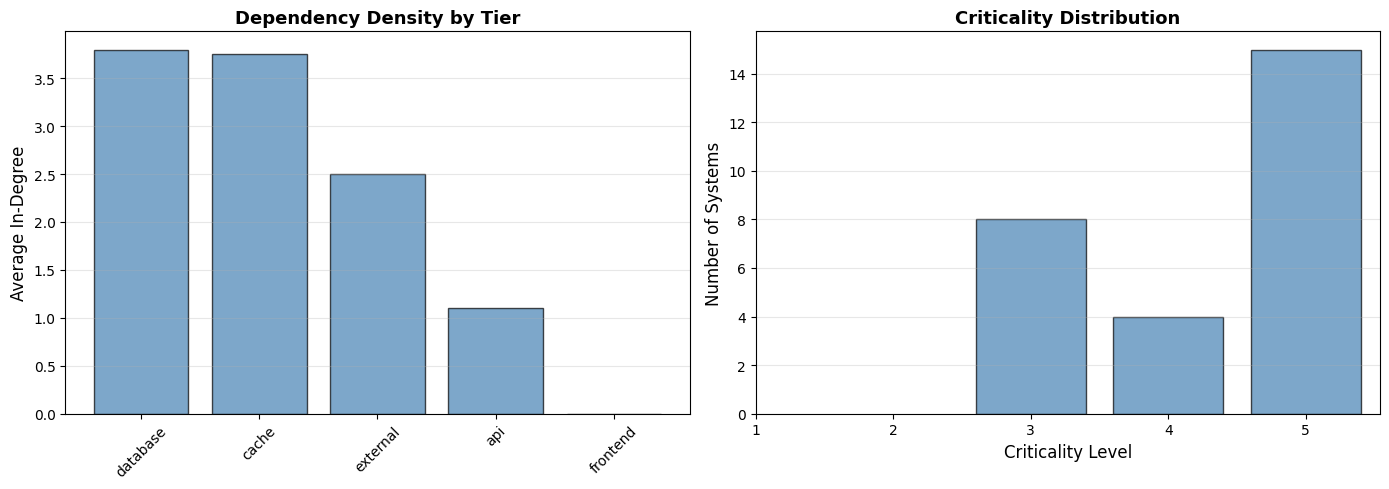

In [26]:
# Visualization: System importance by tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Average in-degree by tier
tier_in_degree = metrics_df.groupby('Tier')['In-Degree'].mean().sort_values(ascending=False)
axes[0].bar(range(len(tier_in_degree)), tier_in_degree.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(tier_in_degree)))
axes[0].set_xticklabels(tier_in_degree.index, rotation=45)
axes[0].set_ylabel('Average In-Degree', fontsize=12)
axes[0].set_title('Dependency Density by Tier', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Right: System criticality distribution
criticality_counts = metrics_df['Criticality'].value_counts().sort_index()
axes[1].bar(criticality_counts.index, criticality_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Criticality Level', fontsize=12)
axes[1].set_ylabel('Number of Systems', fontsize=12)
axes[1].set_title('Criticality Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(1, 6))

plt.tight_layout()
plt.show()

## 12. Key Takeaways

### Why Paths & Dependencies Matter

Your system's performance is limited by its longest dependency chain (critical path). Find it, optimize it.

### When to Use Each Algorithm

| Algorithm | Use Case | Output |
|-----------|----------|--------|
| **Shortest Path** | Fast recovery after failure | Minimum hops or latency |
| **Critical Path** | Identify bottleneck | Longest chain; prioritize optimization |
| **Topological Sort** | Deployment/boot order | Respects all dependencies |
| **SCC / Cycle Detection** | Prevent deadlocks | Find circular dependencies |
| **Articulation Points** | Identify single failures | Critical systems needing redundancy |

### Common Pitfalls

1. **Optimizing the wrong system** — Optimize critical path systems only (biggest impact)
2. **Ignoring latency** — Shortest by hops ≠ shortest by latency (both matter)
3. **Missing single points of failure** — High in-degree + no alternatives = risky
4. **Allowing circular dependencies** — Deadlocks prevent deployment
5. **Wrong deployment order** — Boot order matters (respect dependency DAG)

In [ ]:
# Print Key Findings Summary
print("\n" + "="*60)
print("KEY FINDINGS (This Dataset)")
print("="*60)

if len(critical_path) > 0:
    bottleneck_name = systems_df[systems_df['system_id'] == critical_path[0]]['name'].values[0]
    bottleneck_latency = systems_df[systems_df['system_id'] == critical_path[0]]['latency_ms'].values[0]
    print(f"\nCritical Path Analysis:")
    print(f"  • Length: {len(critical_path)} systems, {critical_latency:.0f}ms total latency")
    print(f"  • Bottleneck System: {bottleneck_name} ({bottleneck_latency:.0f}ms)")
    print(f"  • Optimization ROI: Every 1ms saved = 1ms faster for entire system")

print(f"\nResilience Analysis:")
print(f"  • Single Points of Failure: {len(articulation_points)} articulation points")
if len(articulation_points) > 0:
    print(f"    → These {len(articulation_points)} systems need redundancy")
else:
    print(f"    → Network is robust (no single points of failure)")

print(f"\nDeployment:")
print(f"  • Systems: {G.number_of_nodes()}")
print(f"  • Dependencies: {G.number_of_edges()}")
print(f"  • Deployment Order: {len(topo_order)} systems in boot sequence")
print(f"  • Circular Dependencies: None (DAG confirmed)")

print(f"\nRedundancy Recommendations:")
print(f"  • Top 3 systems to add redundancy to:")
for i, (_, row) in enumerate(redundancy_rec.head(3).iterrows(), 1):
    print(f"    {i}. {row['System']} (score: {row['Redundancy_Score']:.0f})")

print("\n" + "="*60 + "\n")

---

**Congratulations!** You now understand that systems depend on systems, forming chains. The longest chain is your bottleneck—fix it for maximum ROI.

**In real systems**:
- Database is usually the bottleneck (slowest layer)
- Adding cache helps if you're database-bound
- Redundancy for critical systems prevents cascading failures
- Topological order prevents deployment deadlocks

**Next lesson**: Graph Algorithms II — Advanced topics in shortest paths, flow networks, and optimization.